# **INTRO**

1. [Daten](#1)
* Modelle:

    1. [Naive Bayes](#3)
    1. [Support Vector Machine (SVM)](#4)
    1. [KNN - K NEAREST NEIGHBOUR](#5)
    1. [Decision Tree](#6)
    1. [Random Forest](#7)
* [Vergleich](#8)   

This dataset contains 7 features and a label column.

* long_hair - This column contains 0's and 1's where 1 is "long hair" and 0 is "not long hair".

* forehead_width_cm - This column is in cm's. This is the width of the forehead.

* forehead_height_cm - This is the height of the forehead and it's in Cm's.

* nose_wide - This column contains 0's and 1's where 1 is "wide nose" and 0 is "not wide nose".

* nose_long - This column contains 0's and 1's where 1 is "Long nose" and 0 is "not long nose".

* lips_thin - This column contains 0's and 1's where 1 represents the "thin lips" while 0 is "Not thin lips".

* distance_nose_to_lip_long - This column contains 0's and 1's where 1 represents the "long distance between nose and lips" while 0 is "short distance between nose and lips".

* gender - This is either "Male" or "Female".

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')
from sklearn.metrics import confusion_matrix

# Mount des Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


<a id = "1"></a><br>

# **Daten**

In [2]:
#Lesen der Daten
df = pd.read_csv('/content/drive/MyDrive/data/gender_classification_v7.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


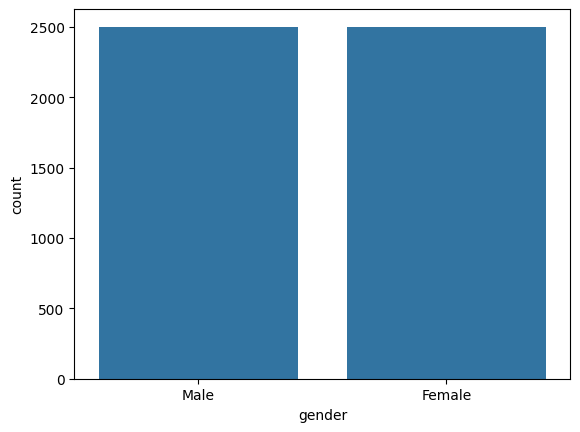

In [4]:
sns.countplot(x='gender', data=df);

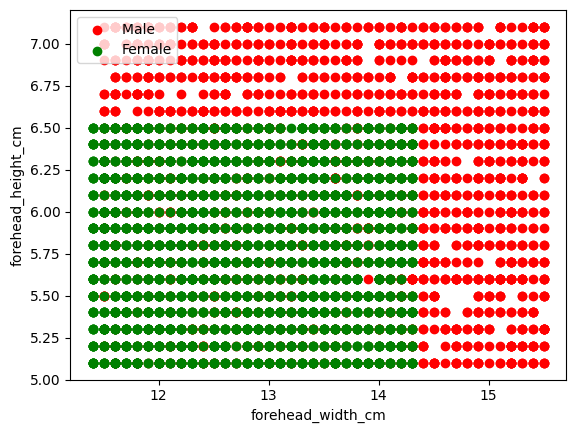

In [5]:
male = df[df.gender == 'Male']
female = df[df.gender == 'Female']
plt.scatter(male.forehead_width_cm, male.forehead_height_cm, color='red', label='Male ')
plt.scatter(female.forehead_width_cm, female.forehead_height_cm, color='green', label='Female')
plt.xlabel('forehead_width_cm')
plt.ylabel('forehead_height_cm')
plt.legend()
plt.show()

In [6]:
y = df.gender.values
x = df.drop('gender', axis=1)
print(y)

['Male' 'Female' 'Male' ... 'Female' 'Female' 'Male']


In [7]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
print(y)

[1 0 1 ... 0 0 1]


<a id = "2"></a><br>

# **Modelle**
## **Logistic Regression**

* *`Obwohl es "Regression" heisst, ist es eine Klassifikation`*

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.33, random_state=11)
logistic_regression = LogisticRegression()
logistic_regression.fit(x_train, y_train)

LogisticRegression()

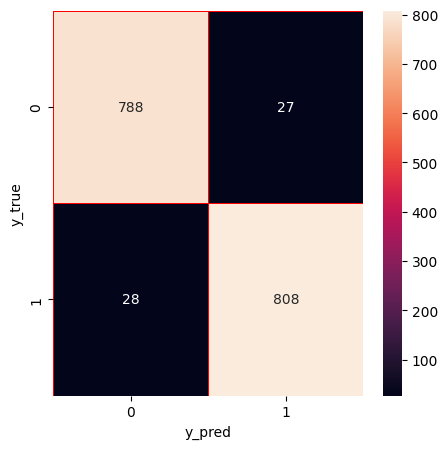

In [10]:
y_pred =  logistic_regression.predict(x_test)
y_true = y_test
confmatrix = confusion_matrix(y_true,y_pred)
f, ax =  plt.subplots(figsize=(5,5))
sns.heatmap(confmatrix, annot=True, linewidths=0.5, linecolor='red', fmt='.0f', ax=ax)
plt.xlabel('y_pred')
plt.ylabel('y_true')
plt.show()

In [11]:
print('Test accuracy: ', logistic_regression.score(x_test, y_test))

Test accuracy:  0.966686856450636


<a id = "3"></a><br>

## **Naive Bayes Classifaction**


In [12]:
from sklearn.naive_bayes import GaussianNB

In [13]:
navie_bayes = GaussianNB()
navie_bayes.fit(x_train, y_train)
print('Test accuracy: ', navie_bayes.score(x_test, y_test))

Test accuracy:  0.9678982434887947


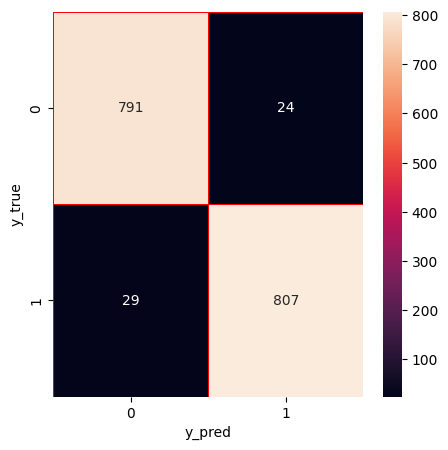

In [14]:
y_pred =  navie_bayes.predict(x_test)
y_true = y_test
confmatrix = confusion_matrix(y_true,y_pred)
f, ax =  plt.subplots(figsize=(5,5))
sns.heatmap(confmatrix, annot=True, linewidths=0.5, linecolor='red', fmt='.0f', ax=ax)
plt.xlabel('y_pred')
plt.ylabel('y_true')
plt.show()

<a id = "4"></a><br>

## **Support Vector Machine (SVM) Classifaction**



In [15]:
from sklearn.svm import SVC

In [16]:
super_vector_machiine = SVC(random_state=1)
super_vector_machiine.fit(x_train, y_train)
print('Test accuracy: ', super_vector_machiine.score(x_test, y_test))

Test accuracy:  0.966686856450636


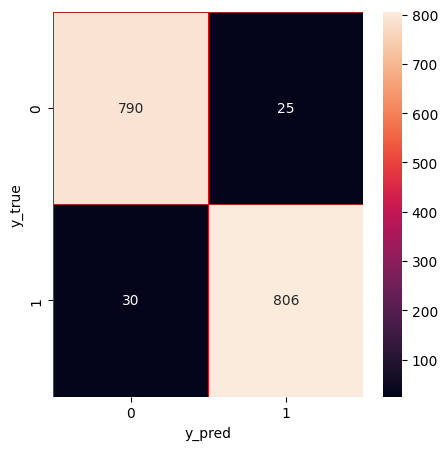

In [17]:
y_pred =  super_vector_machiine.predict(x_test)
y_true = y_test
confmatrix = confusion_matrix(y_true,y_pred)
f, ax =  plt.subplots(figsize=(5,5))
sns.heatmap(confmatrix, annot=True, linewidths=0.5, linecolor='red', fmt='.0f', ax=ax)
plt.xlabel('y_pred')
plt.ylabel('y_true')
plt.show()

<a id = "5"></a><br>

## **KNN - K NEAREST NEIGHBOUR**



In [18]:
from sklearn import preprocessing
x = preprocessing.normalize(x)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)
knn.predict(x_test)

array([0, 1, 1, ..., 0, 1, 0])

In [20]:
print('Test Accuracy: ', knn.score(x_test,y_test))

Test Accuracy:  0.9582071471835252


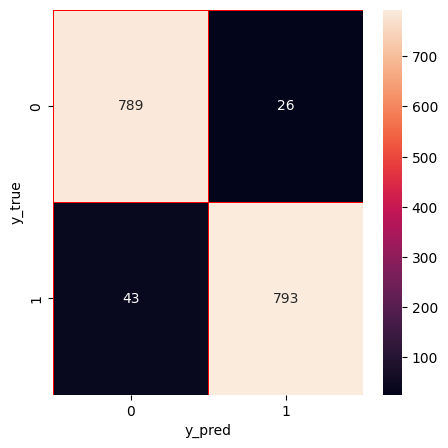

In [21]:
y_pred =  knn.predict(x_test)
y_true = y_test
confmatrix = confusion_matrix(y_true,y_pred)
f, ax =  plt.subplots(figsize=(5,5))
sns.heatmap(confmatrix, annot=True, linewidths=0.5, linecolor='red', fmt='.0f', ax=ax)
plt.xlabel('y_pred')
plt.ylabel('y_true')
plt.show()

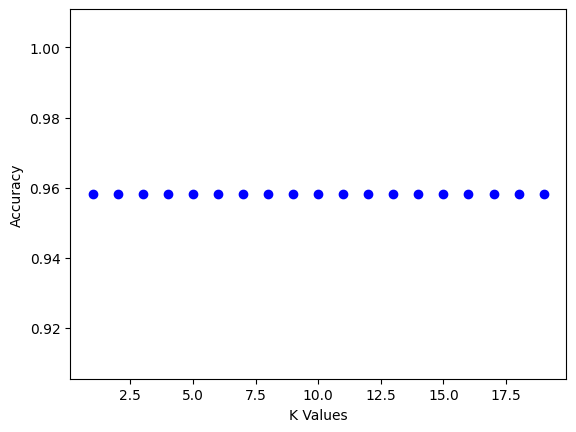

In [22]:
k_values = []
for i in range(1,20):
    knn2 = KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    k_values.append(knn.score(x_test,y_test))

plt.scatter(range(1,20), k_values, color='blue')
plt.xlabel('K Values')
plt.ylabel('Accuracy')
plt.show()

<a id = "6"></a><br>

## **Decision Tree Classifaction**



In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.tree import export_text

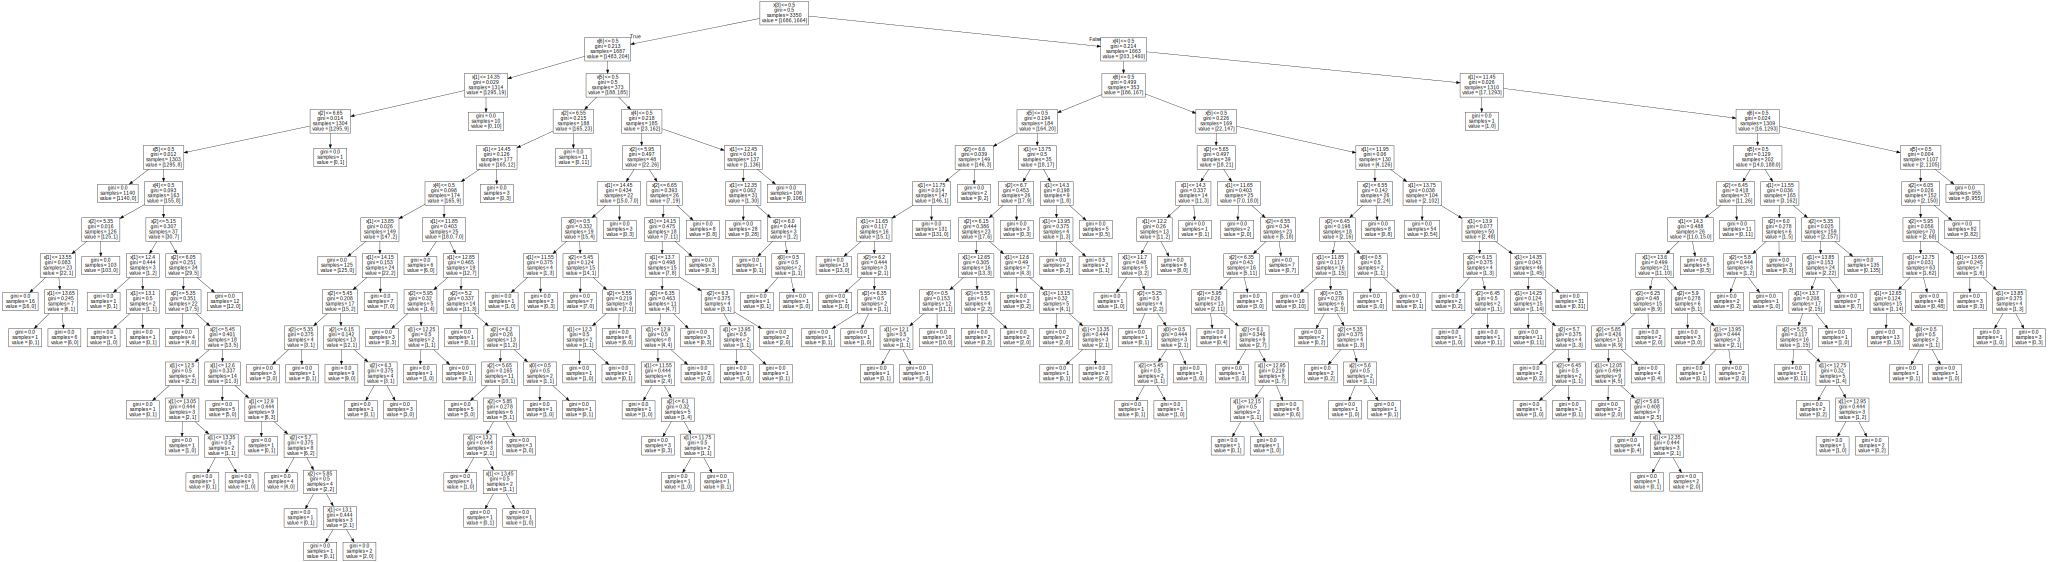

In [24]:
decision_tree_classifaction = DecisionTreeClassifier()
decision_tree_classifaction.fit(x_train, y_train)

#tree.plot_tree(decision_tree_classifaction)

#Textausgabe
#r = export_text(decision_tree_classifaction)
#print(r)

#als Grafik ausgeben
import graphviz
dot_data = tree.export_graphviz(decision_tree_classifaction, out_file=None)
graph = graphviz.Source(dot_data)
graph

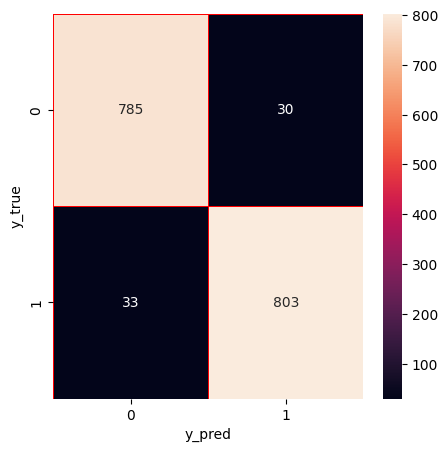

In [25]:
y_pred =  decision_tree_classifaction.predict(x_test)
y_true = y_test
confmatrix = confusion_matrix(y_true,y_pred)
f, ax =  plt.subplots(figsize=(5,5))
sns.heatmap(confmatrix, annot=True, linewidths=0.5, linecolor='red', fmt='.0f', ax=ax)
plt.xlabel('y_pred')
plt.ylabel('y_true')
plt.show()

In [26]:
print('Score: ', decision_tree_classifaction.score(x_test,y_test))

Score:  0.9618413082980012


<a id = "7"></a><br>

## **Random Forest Classifaction**


In [27]:
from sklearn.ensemble import RandomForestClassifier
random_forest_classifaction = RandomForestClassifier(n_estimators=30, random_state=42)
random_forest_classifaction.fit(x_train, y_train)

RandomForestClassifier(n_estimators=30, random_state=42)

In [28]:
print('Score', random_forest_classifaction.score(x_test,y_test))

Score 0.9636583888552392


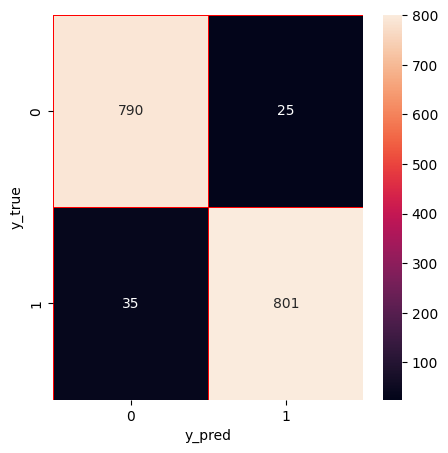

In [29]:
y_pred =  random_forest_classifaction.predict(x_test)
y_true = y_test
confmatrix = confusion_matrix(y_true,y_pred)
f, ax =  plt.subplots(figsize=(5,5))
sns.heatmap(confmatrix, annot=True, linewidths=0.5, linecolor='red', fmt='.0f', ax=ax)
plt.xlabel('y_pred')
plt.ylabel('y_true')
plt.show()

<a id = "8"></a><br>

# **abschliessender Vergleich**

LogisticRegression() Score:  0.966686856450636


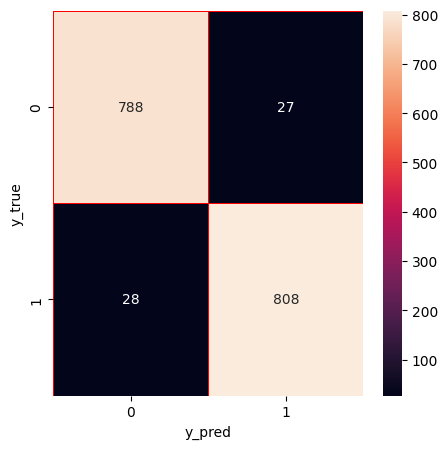

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
GaussianNB() Score:  0.9678982434887947


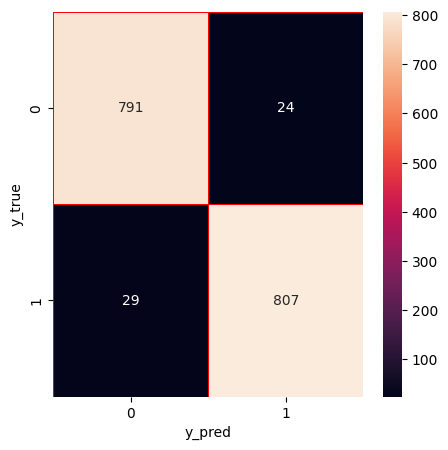

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
SVC(random_state=1) Score:  0.966686856450636


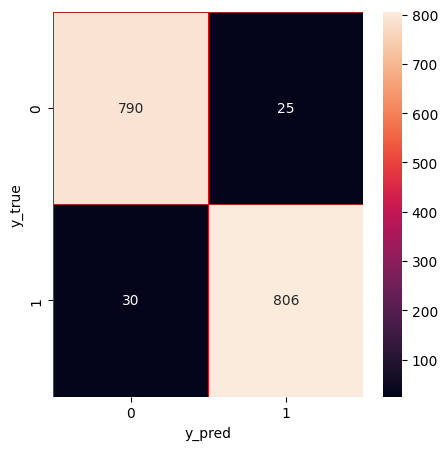

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
KNeighborsClassifier(n_neighbors=3) Score:  0.9582071471835252


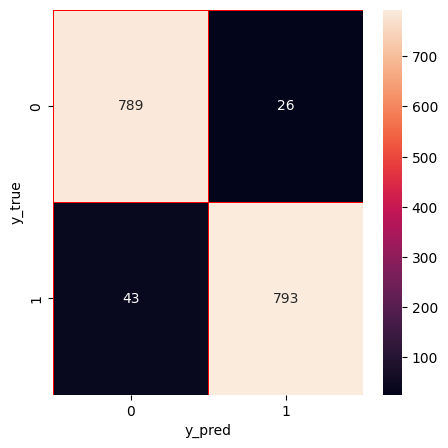

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
DecisionTreeClassifier() Score:  0.9618413082980012


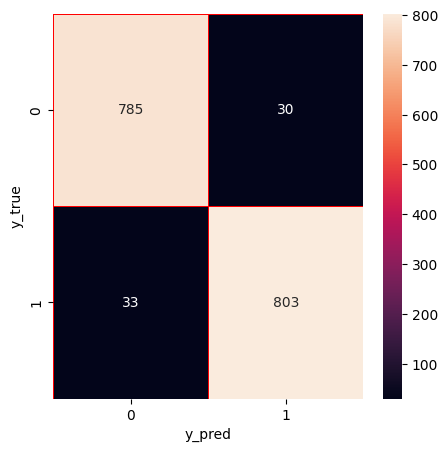

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
RandomForestClassifier(n_estimators=30, random_state=42) Score:  0.9636583888552392


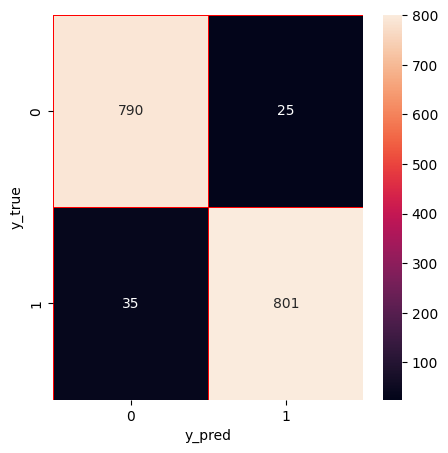

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


In [30]:
modelsName = [logistic_regression,navie_bayes,super_vector_machiine,knn,decision_tree_classifaction,random_forest_classifaction]
for n in modelsName:
    print(f'{n} Score: ', n.score(x_test,y_test))

    y_pred =  n.predict(x_test)
    y_true = y_test
    confmatrix = confusion_matrix(y_true,y_pred)
    f, ax =  plt.subplots(figsize=(5,5))
    sns.heatmap(confmatrix, annot=True, linewidths=0.5, linecolor='red', fmt='.0f', ax=ax)
    plt.xlabel('y_pred')
    plt.ylabel('y_true')
    plt.show()
    print('~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~')
